In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(r"C:\Users\kesha\Downloads\Sample - Superstore (1).csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year


In [4]:
df = df.drop_duplicates()
df = df.dropna()


In [5]:
cube = df.groupby(["Year","Category","Region"])["Sales"].sum().reset_index()

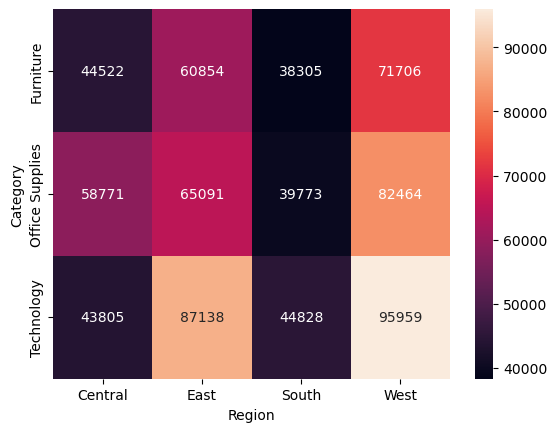

In [6]:
latest_year = df["Year"].max()
heat = df[df["Year"]==latest_year].pivot_table(
    values="Sales", index="Category", columns="Region", aggfunc="sum"
)
sns.heatmap(heat, annot=True, fmt=".0f")
plt.show()


In [7]:
cat_year = df.groupby(["Year","Category"])["Sales"].sum().unstack()
growth = cat_year.pct_change()*100


In [8]:
top_category = df.groupby("Category")["Sales"].sum().idxmax()
subcat_sales = df[df["Category"]==top_category] \
    .groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)


In [9]:
slice_df = df[df["Year"]==2017]
slice_summary = slice_df.groupby(["Category","Region"])["Sales"].sum()


In [11]:
dice_df = df[(df["Year"]==2017) &
             (df["Region"]=="West") &
             (df["Category"]=="Technology")]
dice_result = dice_df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)



In [15]:
print(dice_result)

Sub-Category
Copiers        29459.676
Accessories    26029.692
Phones         24691.520
Machines       15778.260
Name: Sales, dtype: float64


In [16]:
print(dice_df)

      Row ID        Order ID Order Date   Ship Date       Ship Mode  \
205      206  CA-2017-108329 2017-12-09  12/14/2017  Standard Class   
345      346  CA-2017-169901 2017-06-15   6/19/2017  Standard Class   
405      406  CA-2017-117457 2017-12-08  12/12/2017  Standard Class   
406      407  CA-2017-117457 2017-12-08  12/12/2017  Standard Class   
486      487  CA-2017-140963 2017-06-10   6/13/2017     First Class   
...      ...             ...        ...         ...             ...   
9685    9686  CA-2017-118668 2017-01-02    1/4/2017    Second Class   
9700    9701  CA-2017-154116 2017-12-15  12/19/2017  Standard Class   
9725    9726  CA-2017-142293 2017-09-17   9/20/2017     First Class   
9941    9942  CA-2017-164028 2017-11-24  11/30/2017  Standard Class   
9991    9992  CA-2017-121258 2017-02-26    3/3/2017  Standard Class   

     Customer ID     Customer Name      Segment        Country           City  \
205     LE-16810   Laurel Elliston     Consumer  United States    